# 01 — Data Loading & Preprocessing
Φόρτωση του FICO HELOC dataset, εξερεύνηση δεδομένων (EDA),
αντιμετώπιση missing values, και προετοιμασία για εκπαίδευση μοντέλων.

## 1. Εισαγωγή βιβλιοθηκών

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

# Ρυθμίσεις εμφάνισης
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("Βιβλιοθήκες φορτώθηκαν επιτυχώς.")

Βιβλιοθήκες φορτώθηκαν επιτυχώς.


## 2. Φόρτωση dataset

In [108]:
import os

# Relative path από τον φάκελο code/ προς τον φάκελο data/
DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data', 'heloc_dataset_v1.csv')

# Φόρτωση
df = pd.read_csv(DATA_PATH)

print(f"Dataset φορτώθηκε: {df.shape[0]} εγγραφές, {df.shape[1]} στήλες")
print(f"Path: {DATA_PATH}")

Dataset φορτώθηκε: 10459 εγγραφές, 24 στήλες
Path: d:\Files\Σχολή\Διπλωματική\thesis-credit-risk\data\heloc_dataset_v1.csv


## 3. Πρώτη ματιά στα δεδομένα


In [109]:
# Πρώτες 5 εγγραφές
df.head()

,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,MaxDelqEver,NumTotalTrades,NumTradesOpeninLast12M,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
0,Bad,55,144,4,84,20,3,0,83,2,3,5,23,1,43,0,0,0,33,-8,8,1,1,69
1,Bad,61,58,15,41,2,4,4,100,-7,0,8,7,0,67,0,0,0,0,-8,0,-8,-8,0
2,Bad,67,66,5,24,9,0,0,100,-7,7,8,9,4,44,0,4,4,53,66,4,2,1,86
3,Bad,66,169,1,73,28,1,1,93,76,6,6,30,3,57,0,5,4,72,83,6,4,3,91
4,Bad,81,333,27,132,12,0,0,100,-7,7,8,12,0,25,0,1,1,51,89,3,1,0,80


In [110]:
# Τύποι δεδομένων και μη-null τιμές
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10459 entries, 0 to 10458
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   RiskPerformance                     10459 non-null  str  
 1   ExternalRiskEstimate                10459 non-null  int64
 2   MSinceOldestTradeOpen               10459 non-null  int64
 3   MSinceMostRecentTradeOpen           10459 non-null  int64
 4   AverageMInFile                      10459 non-null  int64
 5   NumSatisfactoryTrades               10459 non-null  int64
 6   NumTrades60Ever2DerogPubRec         10459 non-null  int64
 7   NumTrades90Ever2DerogPubRec         10459 non-null  int64
 8   PercentTradesNeverDelq              10459 non-null  int64
 9   MSinceMostRecentDelq                10459 non-null  int64
 10  MaxDelq2PublicRecLast12M            10459 non-null  int64
 11  MaxDelqEver                         10459 non-null  int64
 12  NumTotalTrades 

In [111]:
# Βασικά στατιστικά
df.describe()

,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,MaxDelqEver,NumTotalTrades,NumTradesOpeninLast12M,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
count,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00,10459.00
mean,67.43,184.21,8.54,73.84,19.43,0.04,-0.14,86.66,6.76,4.93,5.51,20.86,1.25,32.17,-0.33,0.87,0.81,31.63,39.16,3.19,0.98,0.02,62.08
std,21.12,109.68,13.30,38.78,13.00,2.51,2.37,26.00,20.50,3.76,3.97,14.58,3.07,20.13,6.07,3.18,3.14,30.06,42.10,4.41,4.06,3.36,27.71
min,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00,-9.00
25%,63.00,118.00,3.00,52.00,12.00,0.00,0.00,87.00,-7.00,4.00,5.00,12.00,0.00,20.00,-7.00,0.00,0.00,5.00,-8.00,2.00,1.00,0.00,47.00
50%,71.00,178.00,5.00,74.00,19.00,0.00,0.00,96.00,-7.00,6.00,6.00,20.00,1.00,31.00,0.00,1.00,1.00,25.00,47.00,3.00,2.00,0.00,67.00
75%,79.00,249.50,11.00,95.00,27.00,1.00,0.00,100.00,14.00,7.00,8.00,29.00,3.00,44.00,1.00,2.00,2.00,54.00,79.00,5.00,3.00,1.00,82.00
max,94.00,803.00,383.00,383.00,79.00,19.00,19.00,100.00,83.00,9.00,8.00,104.00,19.00,100.00,24.00,66.00,66.00,232.00,471.00,32.00,23.00,18.00,100.00


In [112]:
# Κατανομή target variable
print("Κατανομή target variable (RiskPerformance):")
print(df['RiskPerformance'].value_counts())
print()
print("Ποσοστά:")
print(df['RiskPerformance'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Κατανομή target variable (RiskPerformance):
RiskPerformance
Bad     5459
Good    5000
Name: count, dtype: int64

Ποσοστά:
RiskPerformance
Bad     52.2%
Good    47.8%
Name: proportion, dtype: str


## 4. Exploratory Data Analysis (EDA)
### 4.1 Εντοπισμός special values (-9)
Στο HELOC dataset, η τιμή -9 υποδηλώνει missing value.

In [113]:
# Εντοπισμός -9 values ανά στήλη
minus9_counts = (df.drop(columns='RiskPerformance') == -9).sum()
minus9_pct = (minus9_counts / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Count (-9)': minus9_counts,
    'Percentage (%)': minus9_pct
}).query('`Count (-9)` > 0').sort_values('Percentage (%)', ascending=False)

print("Στήλες με special value -9:")
print(missing_df)

Στήλες με special value -9:
                                    Count (-9)  Percentage (%)
ExternalRiskEstimate                       598            5.70
MSinceOldestTradeOpen                      588            5.60
MSinceMostRecentTradeOpen                  588            5.60
AverageMInFile                             588            5.60
NumSatisfactoryTrades                      588            5.60
NumTrades60Ever2DerogPubRec                588            5.60
NumTrades90Ever2DerogPubRec                588            5.60
PercentTradesNeverDelq                     588            5.60
MSinceMostRecentDelq                       588            5.60
MaxDelq2PublicRecLast12M                   588            5.60
MaxDelqEver                                588            5.60
NumTotalTrades                             588            5.60
NumTradesOpeninLast12M                     588            5.60
PercentInstallTrades                       588            5.60
MSinceMostRecentInqexcl7day

### 4.2 Αφαίρεση εγγραφών με -9

In [114]:
# -9 = απουσία πιστωτικού ιστορικού — αποκλείω αντί να impute
# γιατί imputation θα πρόσθετε θόρυβο χωρίς πραγματική πληροφορία
feature_cols = df.columns.drop('RiskPerformance')
df_clean = df[~(df[feature_cols] == -9).any(axis=1)].copy()

print(f"Εγγραφές πριν: {len(df)}")
print(f"Εγγραφές μετά: {len(df_clean)}")
print(f"Αφαιρέθηκαν: {len(df) - len(df_clean)}")
print()
print("Κατανομή target μετά τον καθαρισμό:")
print(df_clean['RiskPerformance'].value_counts())
print(df_clean['RiskPerformance'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Εγγραφές πριν: 10459
Εγγραφές μετά: 9861
Αφαιρέθηκαν: 598

Κατανομή target μετά τον καθαρισμό:
RiskPerformance
Bad     5128
Good    4733
Name: count, dtype: int64
RiskPerformance
Bad     52.0%
Good    48.0%
Name: proportion, dtype: str


## 4.3 Οπτικοποιήσεις EDA


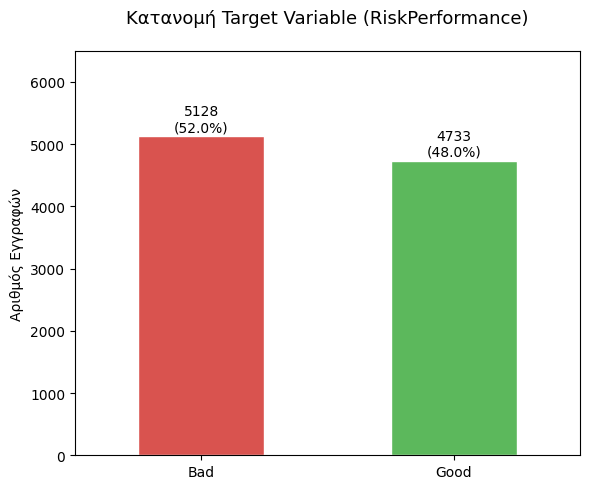

Αποθηκεύτηκε: figures/01_target_distribution.png


In [115]:
# Δημιουργία φακέλου για τα figures
os.makedirs('../figures', exist_ok=True)

# 1. Κατανομή target variable
fig, ax = plt.subplots(figsize=(6, 5))
colors = ['#d9534f', '#5cb85c']
df_clean['RiskPerformance'].value_counts().plot(
    kind='bar', ax=ax, color=colors, edgecolor='white', width=0.5
)
ax.set_title('Κατανομή Target Variable (RiskPerformance)', fontsize=13, pad=20)
ax.set_xlabel('')
ax.set_ylabel('Αριθμός Εγγραφών')
ax.set_xticklabels(['Bad', 'Good'], rotation=0)
for i, v in enumerate(df_clean['RiskPerformance'].value_counts()):
    ax.text(i, v + 80, f'{v}\n({v/len(df_clean)*100:.1f}%)', 
            ha='center', fontsize=10)
ax.set_ylim(0, 6500)
plt.tight_layout()
plt.savefig('../figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/01_target_distribution.png")

### Κατανομές Χαρακτηριστικών

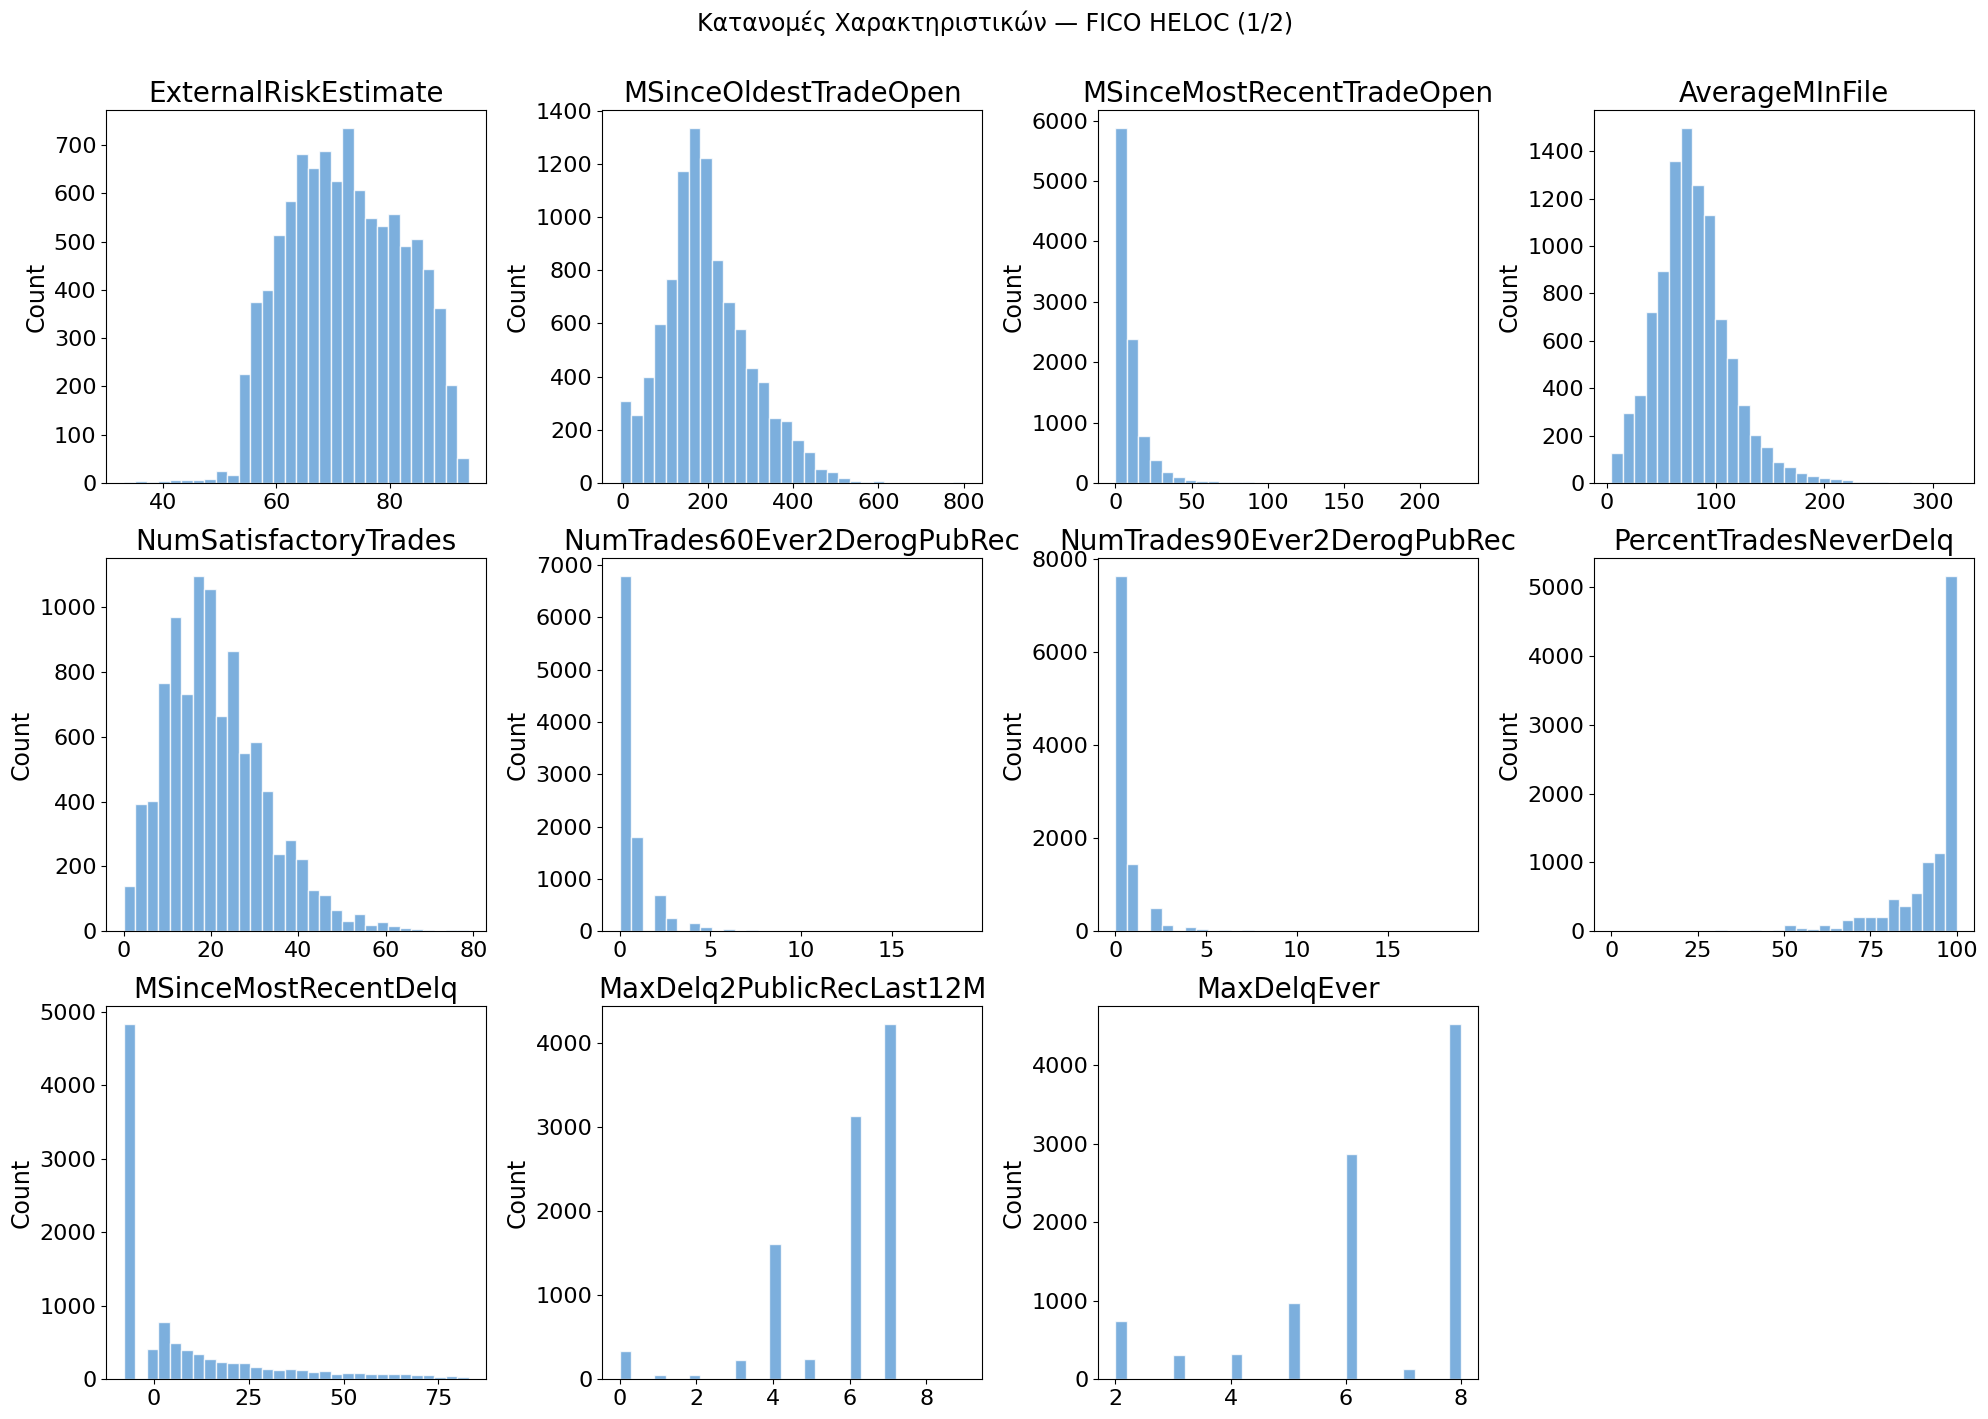

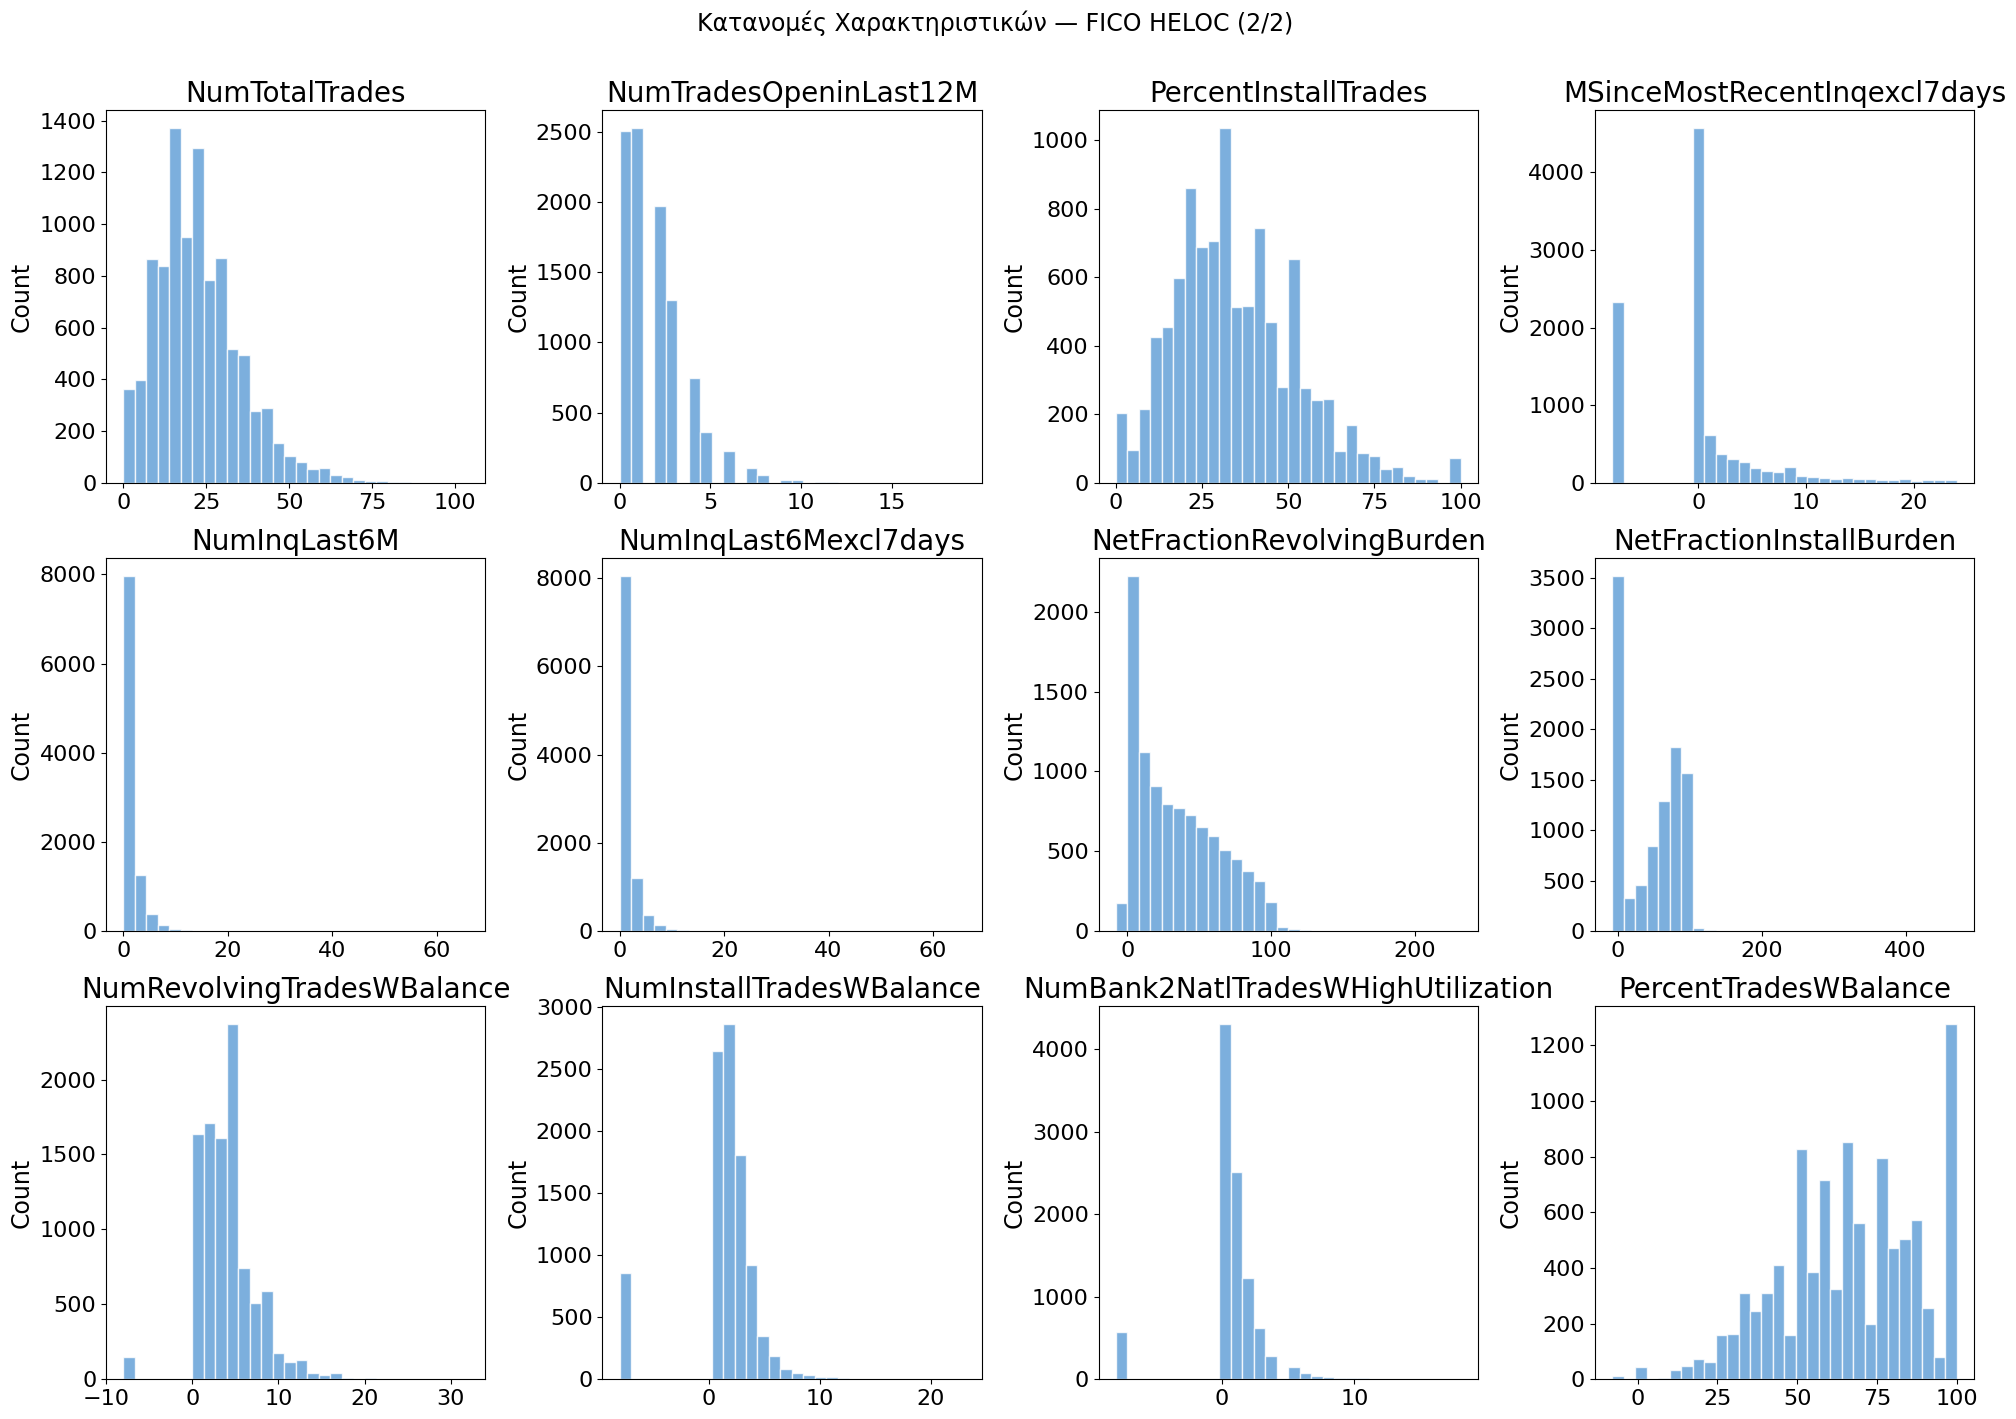

Αποθηκεύτηκε: figures/02_feature_distributions_part1.png και part2.png


In [116]:
# Κατανομές όλων των χαρακτηριστικών
feature_cols = df_clean.columns.drop('RiskPerformance')
mid = len(feature_cols) // 2  # 11 ή 12

for part, cols in enumerate([feature_cols[:mid], feature_cols[mid:]], start=1):
    fig, axes = plt.subplots(3, 4, figsize=(20, 14))
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        axes[i].hist(df_clean[col], bins=30, color='#5b9bd5', 
                     edgecolor='white', alpha=0.8)
        axes[i].set_title(col, fontsize=20)
        axes[i].set_ylabel('Count', fontsize=17)
        axes[i].tick_params(labelsize=16)
    
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(f'Κατανομές Χαρακτηριστικών — FICO HELOC ({part}/2)', 
                 fontsize=17, y=1.01)
    plt.tight_layout()
    plt.savefig(f'../figures/02_feature_distributions_part{part}.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
print("Αποθηκεύτηκε: figures/02_feature_distributions_part1.png και part2.png")

### Correlation Matrix

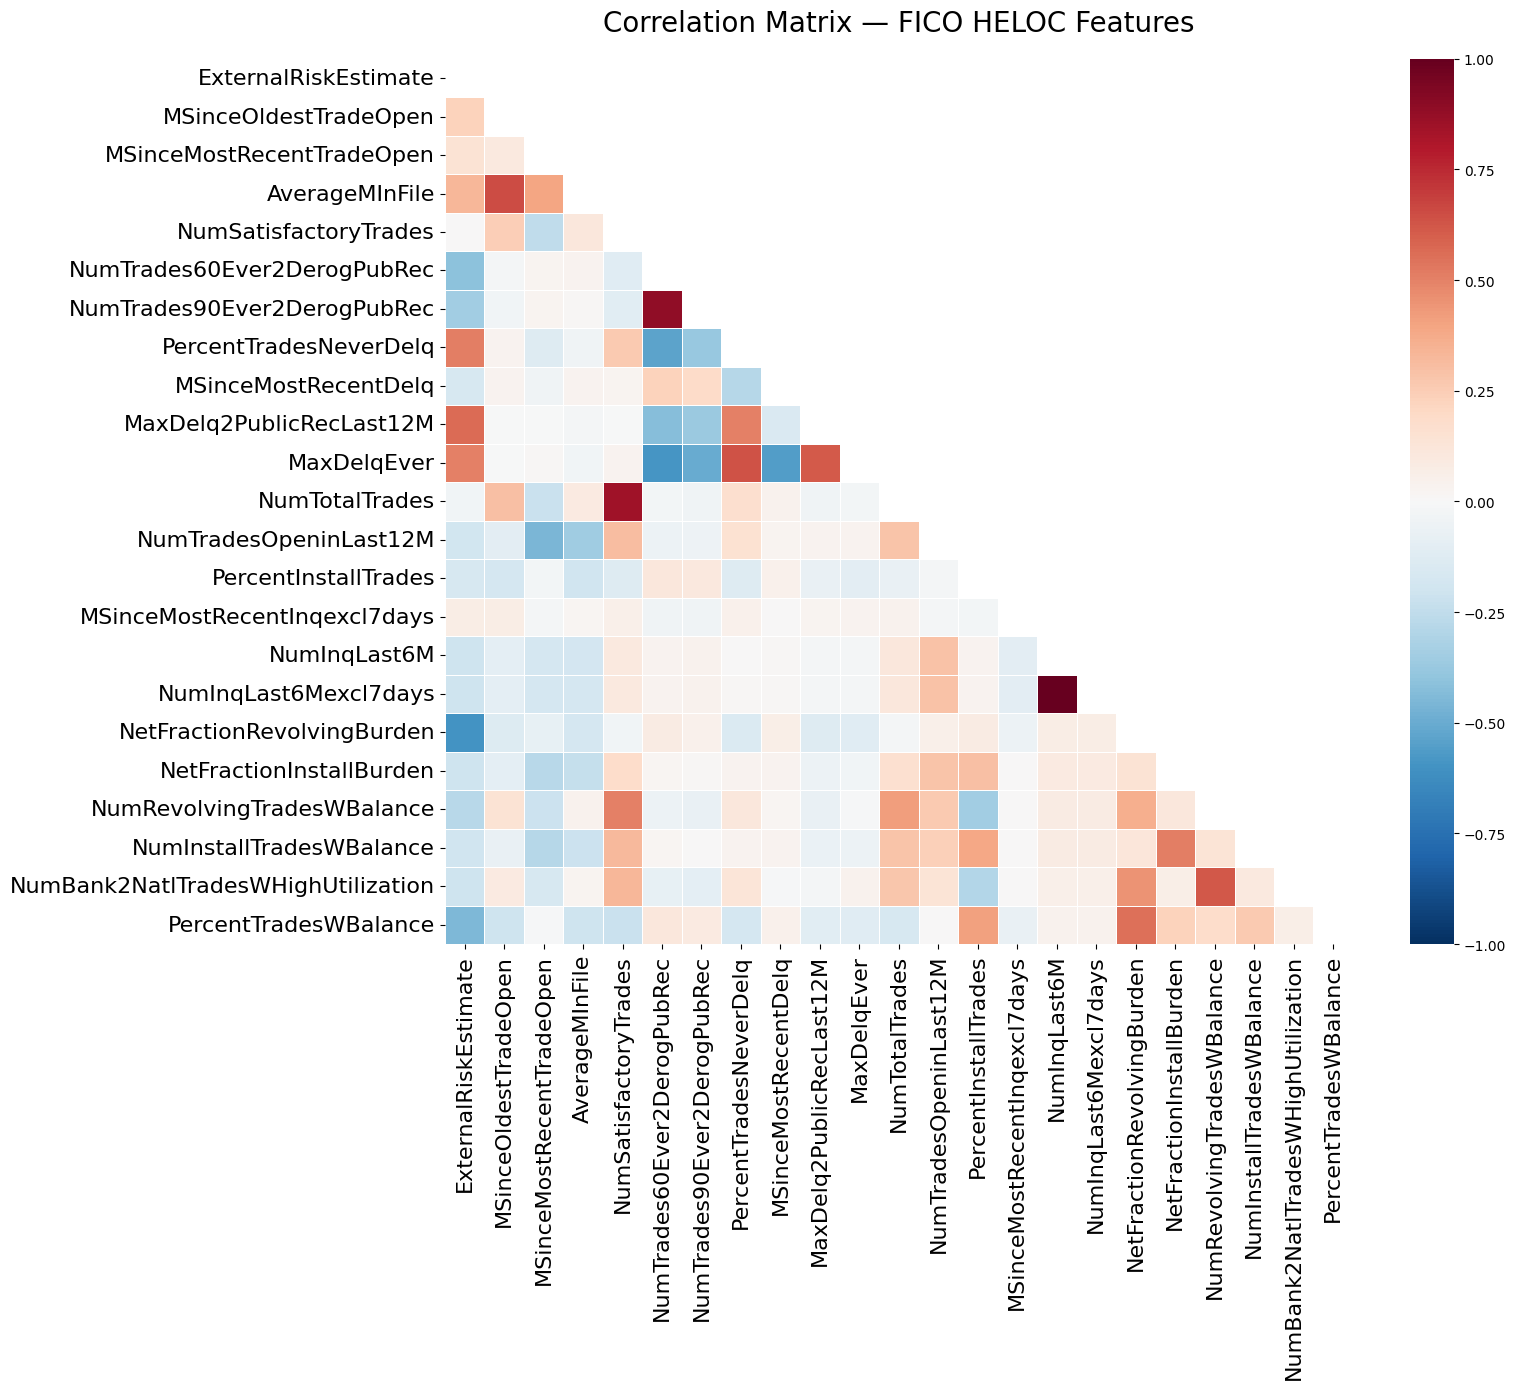

Αποθηκεύτηκε: figures/03_correlation_matrix.png


In [117]:
# Correlation matrix
corr_matrix = df_clean[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))  
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.tick_params(axis='both', labelsize=16)
ax.set_title('Correlation Matrix — FICO HELOC Features', fontsize=20, pad=20)
plt.tight_layout()
plt.savefig('../figures/03_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/03_correlation_matrix.png")

## 5. Προετοιμασία για Εκπαίδευση Μοντέλων
### 5.1 Encoding Target Variable

In [118]:
# Bad=1, Good=0 — positive class = αθέτηση, αυτό θέλουμε να προβλέψουμε
df_clean['target'] = (df_clean['RiskPerformance'] == 'Bad').astype(int)

X = df_clean[feature_cols].values
y = df_clean['target'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Positive class (Bad): {y.sum()} ({y.mean()*100:.1f}%)")

X shape: (9861, 23)
y shape: (9861,)
Positive class (Bad): 5128 (52.0%)


### 5.2 Train / Validation / Test Split (70 / 15 / 15)

In [119]:
# Πρώτο split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Δεύτερο split: 50% του temp = 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train:      {X_train.shape[0]} εγγραφές ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} εγγραφές ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test:       {X_test.shape[0]} εγγραφές ({X_test.shape[0]/len(X)*100:.1f}%)")
print()
print(f"Bad rate — Train:      {y_train.mean()*100:.1f}%")
print(f"Bad rate — Validation: {y_val.mean()*100:.1f}%")
print(f"Bad rate — Test:       {y_test.mean()*100:.1f}%")

Train:      6902 εγγραφές (70.0%)
Validation: 1479 εγγραφές (15.0%)
Test:       1480 εγγραφές (15.0%)

Bad rate — Train:      52.0%
Bad rate — Validation: 52.0%
Bad rate — Test:       52.0%


### 5.3 Scaling
Το scaling εφαρμόζεται μόνο για Logistic Regression και FFNN.
Το XGBoost δεν το χρειάζεται.
Ο scaler εκπαιδεύεται ΜΟΝΟ στο train set για να αποφύγουμε data leakage.

In [120]:
scaler = StandardScaler()

# Fit ΜΟΝΟ στο train set
X_train_scaled = scaler.fit_transform(X_train)

# Transform στα υπόλοιπα
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling ολοκληρώθηκε.")
print(f"Train mean (πρώτη στήλη): {X_train_scaled[:, 0].mean():.4f} (αναμένεται ~0)")
print(f"Train std  (πρώτη στήλη): {X_train_scaled[:, 0].std():.4f} (αναμένεται ~1)")

Scaling ολοκληρώθηκε.
Train mean (πρώτη στήλη): -0.0000 (αναμένεται ~0)
Train std  (πρώτη στήλη): 1.0000 (αναμένεται ~1)


### 5.4 Αποθήκευση επεξεργασμένων δεδομένων

In [121]:
import joblib

# Δημιουργία φακέλου
os.makedirs('../data/processed', exist_ok=True)

# Αποθήκευση arrays
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/X_val.npy', X_val)
np.save('../data/processed/X_test.npy', X_test)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/y_val.npy', y_val)
np.save('../data/processed/y_test.npy', y_test)

# Αποθήκευση scaled arrays
np.save('../data/processed/X_train_scaled.npy', X_train_scaled)
np.save('../data/processed/X_val_scaled.npy', X_val_scaled)
np.save('../data/processed/X_test_scaled.npy', X_test_scaled)

# Αποθήκευση scaler και feature names
joblib.dump(scaler, '../data/processed/scaler.pkl')
np.save('../data/processed/feature_names.npy', np.array(feature_cols))

print("Αποθηκεύτηκαν:")
for f in os.listdir('../data/processed'):
    print(f"  {f}")

Αποθηκεύτηκαν:
  feature_names.npy
  scaler.pkl
  shap_ffnn_sample_20260325_065734.npy
  shap_ffnn_values_20260325_065734.npy
  X_test.npy
  X_test_scaled.npy
  X_train.npy
  X_train_scaled.npy
  X_val.npy
  X_val_scaled.npy
  y_test.npy
  y_train.npy
  y_val.npy
